# IMPORTS

In [1]:
import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s') # NOTSET, DEBUG, INFO, WARN, ERROR, CRITICAL

import os, sys
import torch
import numpy as np

import CL_inference as cl_inference
N_threads = cl_inference.train_tools.set_N_threads_(N_threads=1)
torch.set_num_threads(N_threads)
torch.set_num_interop_threads(N_threads)
device = cl_inference.train_tools.set_torch_device_()

%load_ext autoreload

import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib notebook
plt.style.use('default')
plt.close('all')
font, rcnew = cl_inference.plot_utils.matplotlib_default_config()
mpl.rc('font', **font)
plt.rcParams.update(rcnew)
plt.style.use('tableau-colorblind10')
%config InlineBackend.figure_format = 'retina'

2024-08-09 18:23:53,466 - INFO - N_threads: 1
2024-08-09 18:23:53,496 - INFO - Device: cuda


In [2]:
tmp_CL = "VICReg"

tmp_dataset_str = "v1_v2"
# all
# v1_v2, v1_v3, v2_v3
# f0_f1, f2_f3, f4_f5, f6_f7, f8_f9
# illustris_eagle, bahamas_illustris, eagle_bahamas

In [3]:
NN_split = 20

min_hist = [0., 0., 0., 0., 0.]
# max_hist = [0.1, 0.06, 0.4, 0.3, 0.14]
max_hist = [1.1, 1.1, 1.1, 1.1, 1.1]
Nbins = 40

<IPython.core.display.Javascript object>


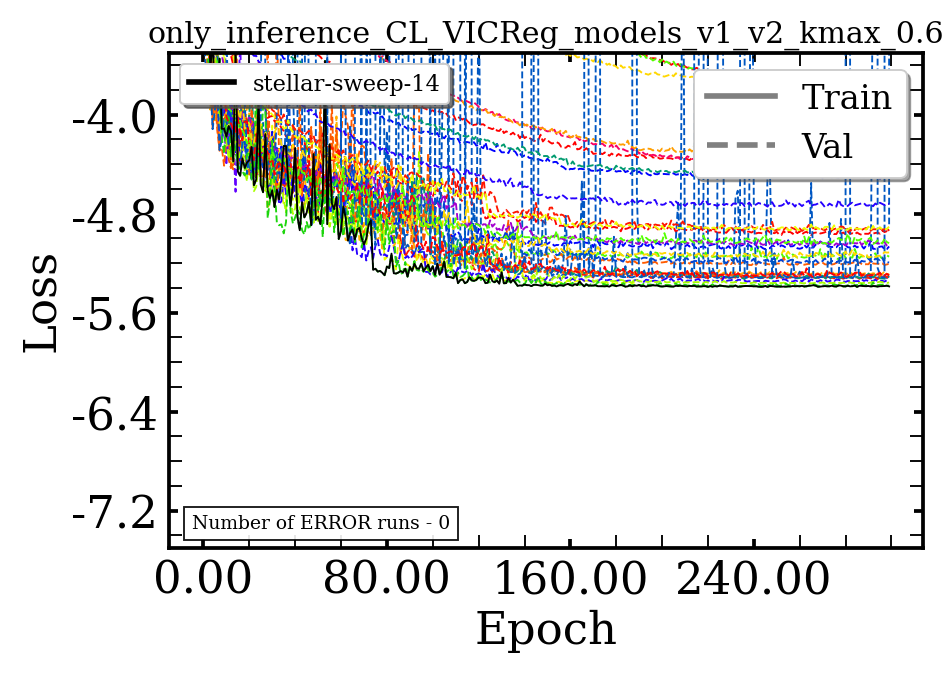

2024-08-09 18:23:54,622 - WARNING - Not value for keywandb_version in stellar-sweep-14


<IPython.core.display.Javascript object>


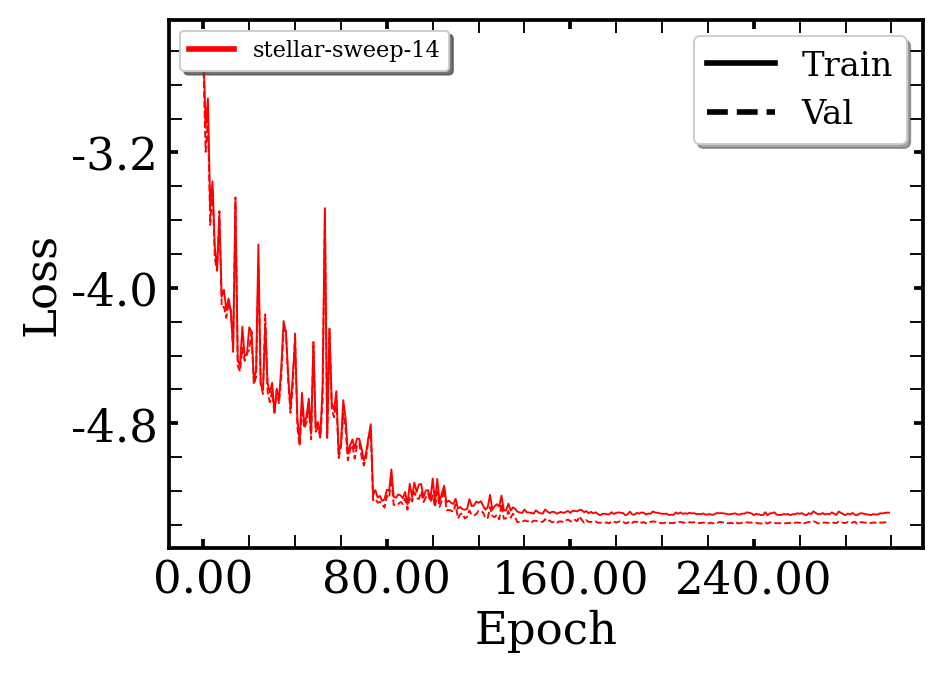

2024-08-09 18:23:54,996 - INFO - Loaded model encoder: hopeful-sweep-18
2024-08-09 18:23:55,018 - INFO - Loaded model inference: stellar-sweep-14


In [4]:
models_path = '/cosmos_storage/home/dlopez/Projects/CL_inference/models/only_inference_CL_'+tmp_CL+'_models_'+tmp_dataset_str+'_kmax_0.6'
configs = cl_inference.plot_utils.get_config_files(models_path, select_N_best_runs=1, wandb_entity="daniellopezcano")

# evalute_mode = 'eval_CL' # "eval_CL", "eval_CL_and_inference", "eval_inference_supervised"
if "only_CL" in models_path:
    evalute_mode = 'eval_CL'
else:
    evalute_mode = 'eval_CL_and_inference'
models_encoder, models_inference = cl_inference.evaluation_tools.reload_models(models_path, evalute_mode, configs, device)

In [5]:
model_name_broadest = "Model_vary_all"
dset_name = "TEST"

key0_dset = list(configs.keys())[0]
sweep_name_load_norm_dset = key0_dset
save_root = configs[key0_dset]["path_save"]
config = configs[sweep_name_load_norm_dset]

list_model_names = [model_name_broadest] + config["list_model_names"]

In [6]:
try:
    print("include_baryon_params:", config['include_baryon_params'])
except:
    config['include_baryon_params'] = False
include_baryon_params = config['include_baryon_params']

try:
    print("dset_type:", config['dset_type'])
except:
    config['dset_type'] = "baccoemu"
dset_type = config['dset_type']

try:
    print("dset_dict:", config['dset_dict'])
except:
    config['dset_dict'] = {
        "add_noise_Pk" : "cosmic_var_gauss",
        "kmax"         : 0.6
    }
    try:
        print("box:", config['box'])
        config['dset_dict'].update({'box' : config['box']})
    except:
        config['dset_dict'].update({'box' : 2000})
    try:
        print("factor_kmin_cut:", config['factor_kmin_cut'])
        config['dset_dict'].update({'factor_kmin_cut' : config['factor_kmin_cut']})
    except:
        config['dset_dict'].update({'factor_kmin_cut' : 4})

In [7]:
custom_titles, limits_plots_inference, list_range_priors, xx_domain, colors, thresholds_bias, NN_bins_hist_bias, NN_bins_hist_err, NN_avail_cosmo_test, NN_split, max_err_hist = cl_inference.plot_utils.get_titles_limits_priors_and_colors_dset_models(
    dset_type             = config['dset_type'],
    dset_dict             = config['dset_dict'],
    list_model_names      = list_model_names,
    include_baryon_params = config['include_baryon_params']
)
list_range_priors = np.array(list_range_priors)

In [8]:
dsets = {}
dsets[dset_name], len_models = cl_inference.data_tools.def_data_loader(
    path_load             = os.path.join(config['path_load'], dset_name),
    list_model_names      = list_model_names,
    dset_type             = dset_type,
    dset_dict             = config['dset_dict'],
    include_baryon_params = include_baryon_params,
    normalize             = config['normalize'],
    path_load_norm        = os.path.join(config['path_save'], sweep_name_load_norm_dset),
    NN_augs_batch         = config['NN_augs_batch'],
    return_len_models     = True
)

2024-08-09 18:23:55,053 - INFO - Defining data loader...
2024-08-09 18:23:55,054 - INFO - Loading stored data...
2024-08-09 18:23:55,055 - INFO - Loading Model_vary_all...
2024-08-09 18:23:55,088 - INFO - Loading Model_vary_1...
2024-08-09 18:23:55,136 - INFO - Loading Model_vary_2...
2024-08-09 18:23:55,196 - INFO - Initializing data loader...
2024-08-09 18:23:55,197 - INFO - Loading normalization parameters...


<IPython.core.display.Javascript object>


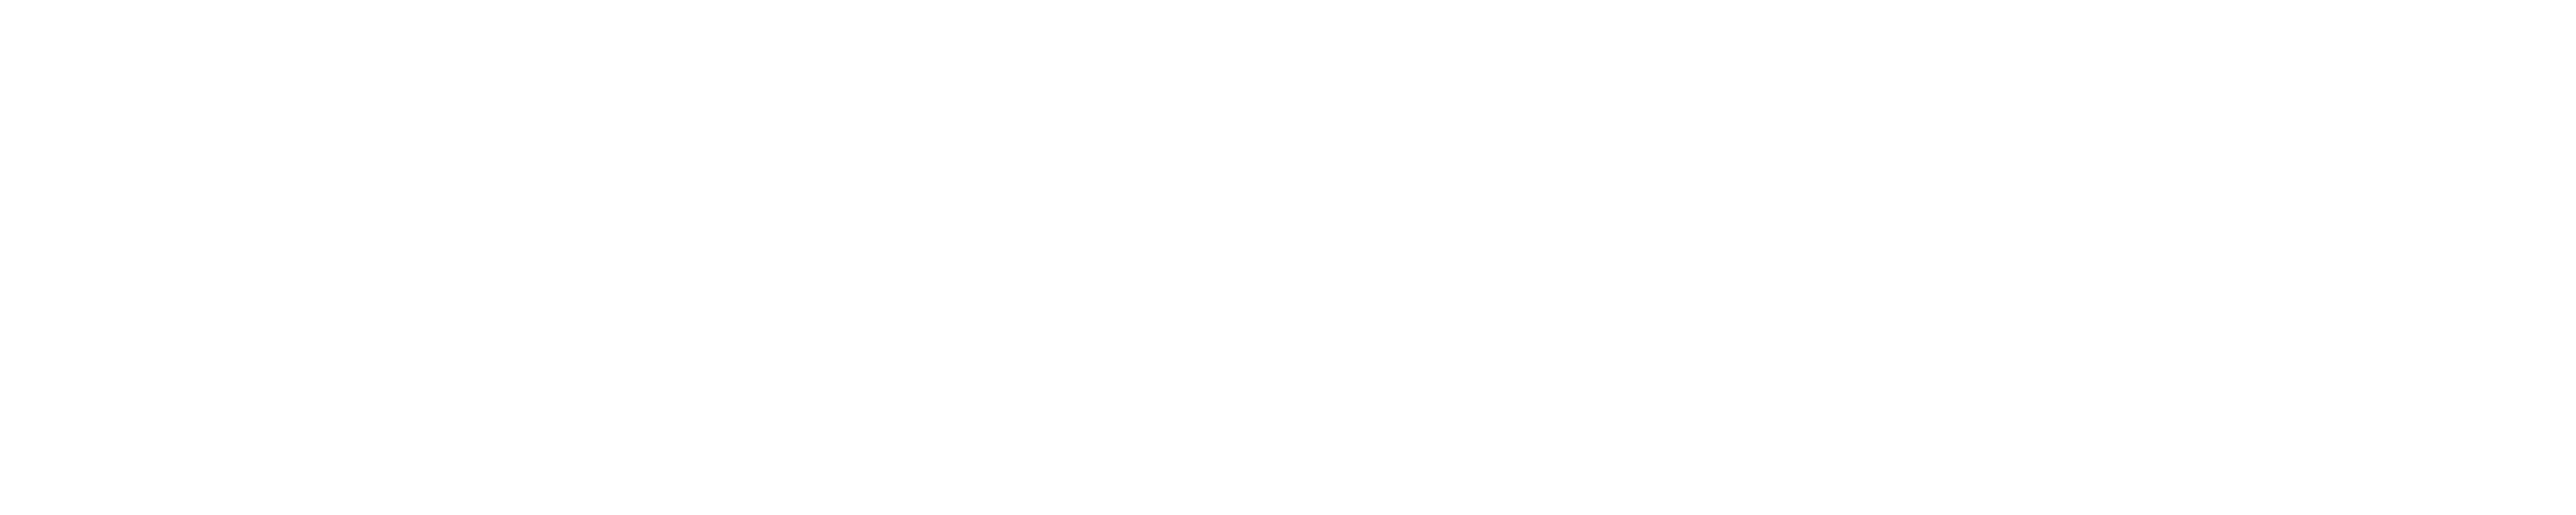

2024-08-09 18:25:21,170 - INFO - Defining data loader...
2024-08-09 18:25:21,171 - INFO - Loading stored data...
2024-08-09 18:25:21,171 - INFO - Loading Model_vary_all...
2024-08-09 18:25:21,188 - INFO - Loading Model_vary_1...
2024-08-09 18:25:21,227 - INFO - Loading Model_vary_2...
2024-08-09 18:25:21,279 - INFO - Initializing data loader...
2024-08-09 18:25:21,280 - INFO - Loading normalization parameters...
2024-08-09 18:25:21,441 - INFO - Defining data loader...
2024-08-09 18:25:21,442 - INFO - Loading stored data...
2024-08-09 18:25:21,443 - INFO - Loading Model_vary_all...
2024-08-09 18:25:21,456 - INFO - Loading Model_vary_1...
2024-08-09 18:25:21,498 - INFO - Loading Model_vary_2...
2024-08-09 18:25:21,550 - INFO - Initializing data loader...
2024-08-09 18:25:21,551 - INFO - Loading normalization parameters...
2024-08-09 18:25:21,716 - INFO - Defining data loader...
2024-08-09 18:25:21,717 - INFO - Loading stored data...
2024-08-09 18:25:21,717 - INFO - Loading Model_vary_all

2024-08-09 18:25:26,434 - INFO - Loading normalization parameters...


In [15]:
N_points = np.zeros((NN_split, len(len_models)))
y_hist = np.zeros((NN_split, len(len_models), len(custom_titles), Nbins+2))
bin_centers = np.zeros((NN_split, len(custom_titles), Nbins+2))

fontsize=26
fontsize1=18
fig, axs = plt.subplots(1, len(custom_titles), figsize=(5.2*len(custom_titles), 5.2))
axs[0].set_ylabel(r'$|\langle Pred.\rangle - True | / \Delta_\mathrm{prior}}$', size=fontsize)

indexes_cosmos = np.arange(dsets[dset_name].xx.shape[0])
np.random.shuffle(indexes_cosmos)
indexes_cosmos_groups = np.split(indexes_cosmos, (np.arange(NN_split)+1) * int(NN_avail_cosmo_test/NN_split))[:-1]
for ii, indexes_cosmos in enumerate(indexes_cosmos_groups):
    xx, hh, theta_true, theta_pred, Cov, len_models = cl_inference.evaluation_tools.compute_dataset_results(
        config,
        sweep_name_load_norm_dset,
        list_model_names=list_model_names,
        models_encoder=models_encoder,
        models_inference=models_inference,
        dset_key="TEST",
        use_all_dataset_augs_ordered=False,
        indexes_cosmo=indexes_cosmos
    )

    dist = np.abs(theta_pred - theta_true) / (list_range_priors[:,1] - list_range_priors[:,0])

    ii_aug = 0
    for ii_model, len_model in enumerate(len_models):
        for ii_cosmo in range(len(custom_titles)):
            ax = axs[ii_cosmo]
            ax.set_title(custom_titles[ii_cosmo], size=fontsize+8, pad=16)
            ax.set_xlabel(r'$\sigma_\mathrm{thr.}$', size=fontsize)
            ax.scatter(
                theta_true[:, ii_aug:ii_aug+len_model, ii_cosmo], dist[:, ii_aug:ii_aug+len_model, ii_cosmo],
                c=colors[ii_model], s=.5, alpha=0.5
            )

            tmp_hist = dist[:, ii_aug:ii_aug+len_model, ii_cosmo]
            counts, bin_edges = np.histogram(tmp_hist, bins=Nbins, range=(min_hist[ii_cosmo], max_hist[ii_cosmo]))
            counts = np.insert(counts, 0, np.sum(tmp_hist<min_hist[ii_cosmo]), axis=0)
            counts = np.insert(counts, len(counts), np.sum(tmp_hist>max_hist[ii_cosmo]), axis=0)

            y_hist[ii, ii_model, ii_cosmo] = counts
            if ii_model == 0:
                tmp_bin_centers = (bin_edges[1:] + bin_edges[:-1])/2
                tmp_bin_centers = np.insert(tmp_bin_centers, 0, tmp_bin_centers[..., 0], axis=-1)
                tmp_bin_centers = np.insert(tmp_bin_centers, tmp_bin_centers.shape[-1], tmp_bin_centers[..., -1], axis=-1)
                bin_centers[ii, ii_cosmo] = tmp_bin_centers
            if ii_cosmo == 0:
                N_points[ii, ii_model] = np.prod(tmp_hist.shape)

        ii_aug += len_model

fig.set_tight_layout(True)

In [ ]:
models_path = '/cosmos_storage/home/dlopez/Projects/CL_inference/models/only_inference_models_'+tmp_dataset_str+'_kmax_0.6'
configs = cl_inference.plot_utils.get_config_files(models_path, select_N_best_runs=1, wandb_entity="daniellopezcano")

# evalute_mode = 'eval_CL' # "eval_CL", "eval_CL_and_inference", "eval_inference_supervised"
if "only_CL" in models_path:
    evalute_mode = 'eval_CL'
else:
    evalute_mode = 'eval_CL_and_inference'
models_encoder, models_inference = cl_inference.evaluation_tools.reload_models(models_path, evalute_mode, configs, device)

In [ ]:
N_points1 = np.zeros((NN_split, len(len_models)))
y_hist1 = np.zeros((NN_split, len(len_models), len(custom_titles), Nbins+2))
bin_centers1 = np.zeros((NN_split, len(custom_titles), Nbins+2))

fontsize=26
fontsize1=18
fig, axs = plt.subplots(1, len(custom_titles), figsize=(5.2*len(custom_titles), 5.2))
axs[0].set_ylabel(r'$|\langle Pred.\rangle - True | / \Delta_\mathrm{prior}}$', size=fontsize)

indexes_cosmos = np.arange(dsets[dset_name].xx.shape[0])
np.random.shuffle(indexes_cosmos)
indexes_cosmos_groups = np.split(indexes_cosmos, (np.arange(NN_split)+1) * int(NN_avail_cosmo_test/NN_split))[:-1]
for ii, indexes_cosmos in enumerate(indexes_cosmos_groups):
    xx, hh, theta_true, theta_pred, Cov, len_models = cl_inference.evaluation_tools.compute_dataset_results(
        config,
        sweep_name_load_norm_dset,
        list_model_names=list_model_names,
        models_encoder=models_encoder,
        models_inference=models_inference,
        dset_key="TEST",
        use_all_dataset_augs_ordered=False,
        indexes_cosmo=indexes_cosmos
    )

    dist = np.abs(theta_pred - theta_true)  / (list_range_priors[:,1] - list_range_priors[:,0])

    ii_aug = 0
    for ii_model, len_model in enumerate(len_models):
        for ii_cosmo in range(len(custom_titles)):
            ax = axs[ii_cosmo]
            ax.set_title(custom_titles[ii_cosmo], size=fontsize+8, pad=16)
            ax.set_xlabel(r'True', size=fontsize)
            ax.scatter(
                theta_true[:, ii_aug:ii_aug+len_model, ii_cosmo],
                dist[:, ii_aug:ii_aug+len_model, ii_cosmo],
                c=colors[ii_model], s=.5, alpha=0.5
            )

            tmp_hist = dist[:, ii_aug:ii_aug+len_model, ii_cosmo]
            counts, bin_edges = np.histogram(tmp_hist, bins=Nbins, range=(min_hist[ii_cosmo], max_hist[ii_cosmo]))
            counts = np.insert(counts, 0, np.sum(tmp_hist<min_hist[ii_cosmo]), axis=0)
            counts = np.insert(counts, len(counts), np.sum(tmp_hist>max_hist[ii_cosmo]), axis=0)

            y_hist1[ii, ii_model, ii_cosmo] = counts
            if ii_model == 0:
                tmp_bin_centers = (bin_edges[1:] + bin_edges[:-1])/2
                tmp_bin_centers = np.insert(tmp_bin_centers, 0, tmp_bin_centers[..., 0], axis=-1)
                tmp_bin_centers = np.insert(tmp_bin_centers, tmp_bin_centers.shape[-1], tmp_bin_centers[..., -1], axis=-1)
                bin_centers1[ii, ii_cosmo] = tmp_bin_centers
            if ii_cosmo == 0:
                N_points1[ii, ii_model] = np.prod(tmp_hist.shape)

        ii_aug += len_model

fig.set_tight_layout(True)

In [ ]:
fontsize=26
fontsize1=18
fig, axs = plt.subplots(1, len(custom_titles), figsize=(5.*len(custom_titles), 5.2))
axs[0].set_ylabel(r'Frac. Points', size=fontsize)

x_store = np.zeros(bin_centers[0].shape)
y_store = np.zeros(bin_centers[0].shape)
y_std_store = np.zeros(bin_centers[0].shape)
y1_store = np.zeros(bin_centers[0].shape)
y1_std_store = np.zeros(bin_centers[0].shape)

ii_model = 0
for ii_cosmo in range(len(custom_titles)):
    ax = axs[ii_cosmo]
    ax.set_title(custom_titles[ii_cosmo], size=fontsize+8, pad=16)
    ax.set_xlabel(r'$|\langle Pred.\rangle - True | / \Delta_\mathrm{prior}$', size=fontsize)
    ax.set_xlim([0., 1.])
    ax.set_ylim([0., 1.])
    if ii_cosmo != 0:
        ax.set_yticks([])

    tmp_x = bin_centers[0, ii_cosmo].T

    tmp_ = np.cumsum(y_hist[:, ii_model, ii_cosmo], axis=-1).T / N_points[:, ii_model]
    tmp_mean = np.mean(tmp_, axis=-1)
    tmp_std = np.std(tmp_, axis=-1)

#     ax.plot(tmp_x, tmp_, c=colors[ii_model], lw=0.2, alpha=0.9, ls='-')
    ax.plot(tmp_x, tmp_mean, c=colors[ii_model], lw=2, ls='-')
#     ax.errorbar(tmp_x, tmp_mean, yerr=tmp_std, c=colors[ii_model], ls='', capsize=2, alpha=1., elinewidth=1.5)
    ax.fill_between(tmp_x, tmp_mean-tmp_std, tmp_mean+tmp_std, color=colors[ii_model], alpha=0.4)

    tmp_1 = np.cumsum(y_hist1[:, ii_model, ii_cosmo], axis=-1).T / N_points1[:, ii_model]
    tmp_mean1 = np.mean(tmp_1, axis=-1)
    tmp_std1 = np.std(tmp_1, axis=-1)

#     ax.plot(tmp_x, tmp_1, c=colors[ii_model], lw=0.2, alpha=0.9, ls='--')
    ax.plot(tmp_x, tmp_mean1, c=colors[ii_model], lw=2, ls='--')
#     ax.errorbar(tmp_x, tmp_mean1, yerr=tmp_std1, c=colors[ii_model], ls='', capsize=2, alpha=1., elinewidth=1.5)
    ax.fill_between(tmp_x, tmp_mean1-tmp_std1, tmp_mean1+tmp_std1, color=colors[ii_model], alpha=0.4)
    
    x_store[ii_cosmo] = tmp_x
    y_store[ii_cosmo] = tmp_mean
    y_std_store[ii_cosmo] = tmp_std
    y1_store[ii_cosmo] = tmp_mean1
    y1_std_store[ii_cosmo] = tmp_std1
    
fig.set_tight_layout(True)

In [ ]:
save_root = "/cosmos_storage/home/dlopez/Projects/CL_inference/models/aux/tmp_store_"+tmp_CL+"/" + tmp_dataset_str 
if not os.path.exists(save_root):
    os.makedirs(save_root)
    
np.save(save_root + "/x_store.npy", x_store)
np.save(save_root + "/y_store.npy", y_store)
np.save(save_root + "/y_std_store.npy", y_std_store)
np.save(save_root + "/y1_store.npy", y1_store)
np.save(save_root + "/y1_std_store.npy", y1_std_store)

In [ ]:
fontsize=26
fontsize1=18
fig, axs = plt.subplots(1, len(custom_titles), figsize=(5.2*len(custom_titles), 5.2))
axs[0].set_ylabel(r'Frac. no CL -' "\n" "Frac. CL", size=fontsize)

y_store = np.zeros(y_hist.shape[1:])
y_std_store = np.zeros(y_hist.shape[1:])
x_store = np.zeros(bin_centers.shape[1:])
for ii_model, len_model in enumerate(len_models):
    for ii_cosmo in range(len(custom_titles)):
        ax = axs[ii_cosmo]
        ax.set_title(custom_titles[ii_cosmo], size=fontsize+8, pad=16)
        ax.set_xlabel(r'$|\langle Pred.\rangle - True | / \Delta_\mathrm{prior}$', size=fontsize)
        ax.axhline(0, c='k', ls=':', lw=0.9)
        
        tmp_x = bin_centers[0, ii_cosmo].T
        
        
        tmp_ = np.cumsum(y_hist[:, ii_model, ii_cosmo], axis=-1).T / N_points[:, ii_model]
        tmp_mean = np.mean(tmp_, axis=-1)
        tmp_std = np.std(tmp_, axis=-1)

        
        tmp_1 = np.cumsum(y_hist1[:, ii_model, ii_cosmo], axis=-1).T / N_points1[:, ii_model]
        tmp_mean1 = np.mean(tmp_1, axis=-1)
        tmp_std1 = np.std(tmp_1, axis=-1)
        
        tmp_y = tmp_mean1 - tmp_mean
        tmp_ystd = (tmp_std1+tmp_std)
        
        x_store[ii_cosmo] = tmp_x
        y_store[ii_model, ii_cosmo] = tmp_y
        y_std_store[ii_model, ii_cosmo] = tmp_ystd
        
        ax.errorbar(x_store[ii_cosmo], y_store[ii_model, ii_cosmo], yerr=(y_std_store[ii_model, ii_cosmo], y_std_store[ii_model, ii_cosmo]),
            color=colors[ii_model], ls='', capsize=2, alpha=1., elinewidth=1.
        )
        ax.fill_between(
            x_store[ii_cosmo], y_store[ii_model, ii_cosmo]-y_std_store[ii_model, ii_cosmo], y_store[ii_model, ii_cosmo]+y_std_store[ii_model, ii_cosmo],
            color=colors[ii_model], alpha=0.3
        )

fig.set_tight_layout(True)

In [ ]:
save_root = "/cosmos_storage/home/dlopez/Projects/CL_inference/models/aux/tmp_store_"+tmp_CL+"/" + tmp_dataset_str 
if not os.path.exists(save_root):
    os.makedirs(save_root)
    
np.save(save_root + "/x_hist_mean_comparison.npy", x_store)
np.save(save_root + "/y_hist_mean_comparison.npy", y_store)
np.save(save_root + "/y_std_hist_mean_comparison.npy", y_std_store)